## Objective
Implement a Support Vector Machine (SVM) model using Python to classify the Breast Cancer dataset.

## Requirements
Use Python + Scikit-learn and perform the following:

Load the dataset (Breast Cancer Dataset): https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset

Perform basic preprocessing (if needed)

Split the data into training and testing sets

Train an SVM model

Evaluate the model

Print: (Accuracy, Confusion Matrix, Classification Report)

## containing:
    Data loading
    Data splitting
    SVM model training
    Model evaluation
    Printed results

## download data

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/breast-cancer-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\moust\.cache\kagglehub\datasets\yasserh\breast-cancer-dataset\versions\1


## import libraries

In [63]:
import os
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler

In [6]:
warnings.filterwarnings('ignore')

## read data

In [8]:
os.listdir(path)

['breast-cancer.csv']

In [9]:
data=pd.read_csv(path+'/breast-cancer.csv')

In [10]:
data.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [11]:
data.shape

(569, 32)

## data preprocessing

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [14]:
data.isna().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [15]:
for i in data.columns:
    if data[i].dtype==object:
        print(data[i].value_counts())
        print('_________________')

diagnosis
B    357
M    212
Name: count, dtype: int64
_________________


In [16]:
le = LabelEncoder()

data['diagnosis'] = le.fit_transform(data['diagnosis'])

In [17]:
data.dtypes

id                           int64
diagnosis                    int32
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [18]:
data.shape

(569, 32)

In [19]:
data.diagnosis.value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

## spiltting data

In [21]:
x=data.drop('diagnosis',axis=1)
y=data.diagnosis

In [22]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42,stratify = y)

In [23]:
scaler=StandardScaler()

In [24]:
X_train_scaled = scaler.fit_transform(xtrain)
X_test_scaled = scaler.transform(xtest)

## train model

In [67]:
model = SVC(kernel='rbf', class_weight='balanced')

model.fit(X_train_scaled, ytrain)

SVC(class_weight='balanced')

## model accuracy

In [28]:
model.score(xtrain,ytrain)

0.37362637362637363

In [69]:
y_pred = model.predict(X_test_scaled)

In [75]:
accuracy_score(ytest, y_pred)

0.9824561403508771

In [77]:
cm = confusion_matrix(ytest, y_pred)

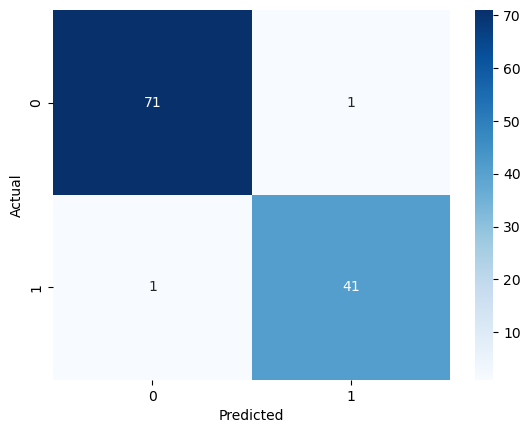

In [83]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [85]:
print(classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        72
           1       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Briefly explain the model results and important features
### lets see the most important features using correlation

In [88]:
corr = data.corr()

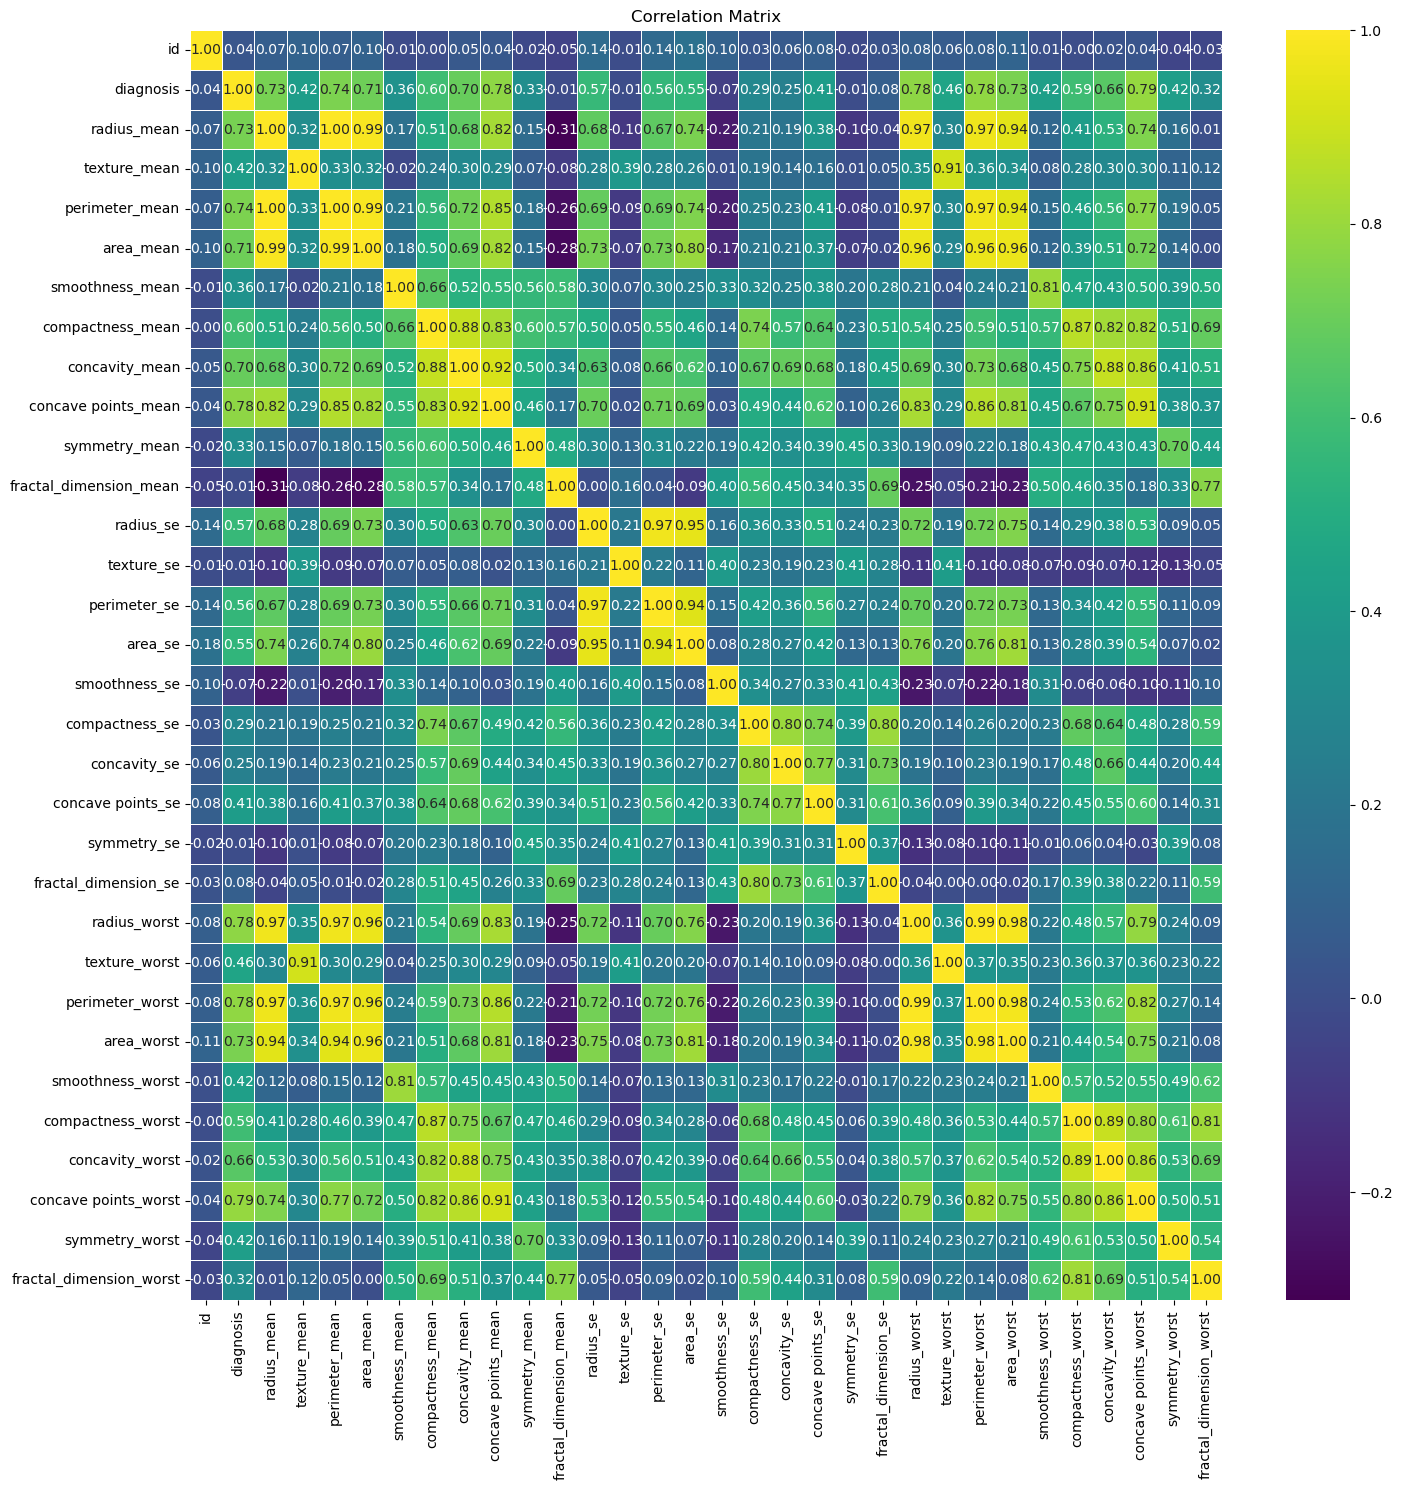

In [90]:
plt.figure(figsize=(15,15))

sns.heatmap(
    corr,
    cmap='viridis',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar=True
)

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()